# Churn Analysis Project

This project investigates why customers stop using a service (churn) and which customer characteristics are most strongly associated with that decision. The goal is to turn these insights into actionable recommendations—such as improving onboarding, pricing, or support—and to support later modeling work for churn prediction.

In [1]:
import sys, os

ROOT_DIR = os.path.abspath("..") 
if ROOT_DIR not in sys.path:
    sys.path.append(ROOT_DIR)

print("Root dir:", ROOT_DIR)

Root dir: /Users/viniciusdesouzamori/Documents/ML_Projects/churn_analysis


# Quick Look at the Dataset

In [2]:
import numpy as np 
import pandas as pd 

from src.data_prep import load_telco_data

df = load_telco_data()
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Each row of the dataset represents 1 client. After the df.head() method, we can see that we have 21 features: customerID, gender, SeniorCitizen, Partner, Dependents, tenure, PhoneService, MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies, Contract, PaperlessBilling, PaymentMethod, MonthlyCharges, TotalCharges and Churn.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


The dataset contains 7,043 customers — small by machine learning standards, but still sufficient for meaningful pattern analysis. All rows are complete, so we don’t need to handle missing values at this stage.

Out of 21 features, 18 are stored as object, meaning they represent text-based categorical attributes such as contract type, payment method, and internet service. Some variables have multiple categories beyond simple Yes/No options, so examining their distribution is important before preprocessing and modeling.

In [4]:
cat_cols = df.select_dtypes(include = "object").columns

print (cat_cols)

for col in cat_cols:
    print(f"\n=== {col} ===")
    print(df[col].value_counts())

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges',
       'Churn'],
      dtype='object')

=== customerID ===
customerID
7590-VHVEG    1
3791-LGQCY    1
6008-NAIXK    1
5956-YHHRX    1
5365-LLFYV    1
             ..
9796-MVYXX    1
2637-FKFSY    1
1552-AAGRX    1
4304-TSPVK    1
3186-AJIEK    1
Name: count, Length: 7043, dtype: int64

=== gender ===
gender
Male      3555
Female    3488
Name: count, dtype: int64

=== Partner ===
Partner
No     3641
Yes    3402
Name: count, dtype: int64

=== Dependents ===
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

=== PhoneService ===
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

=== MultipleLines ===
MultipleLines
No                  3390
Yes                 2971
No phone s

Using df.value_counts() for each categorical feature allows us to inspect the distribution of categories across the dataset. This helps us understand how each feature is structured and informs the decisions we will make later during feature engineering.

A lot of the company’s services seem tied to whether the customer has internet service. Many of the categorical features (like OnlineSecurity, TechSupport, StreamingTV, etc.) are essentially “internet add-ons,” so their values depend on the "InternetService" status (for example, “No internet service”). Because of this, I want to explore "InternetService" as a important factor in my hypotheses and later check how strongly these related features contribute to churn and feature importance.

- Important: When analysing the data, I saw that the "Total Charges" feature is stored as object. To use the df.describe method after, I need to convert it to numerical.

In [5]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors = "coerce")
df[["TotalCharges"]].info(0)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 1 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TotalCharges  7032 non-null   float64
dtypes: float64(1)
memory usage: 55.2 KB


After converting TotalCharges to a numeric type, we discovered some missing values that were previously stored as blank strings. This conversion was important because it makes those missing entries explicit (as NaN), so we can handle them properly during preprocessing (imputation or removal) and train a more reliable model.

In [6]:
df.describe()


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


- SeniorCitizen: The mean is 0.162 for a binary feature (0 or 1), which means that 83.8% of customers are not seniors (according with the description of the dataset, 0 is not senior and 1 is senior). This low variability suggests that the feature may have limited predictive power, because models learn best when a feature shows meaningful variation across the population.
However, it may still be useful if the churn rate among seniors is significantly different from non-seniors. In that case, even a small subgroup can carry predictive signal.

- Tenure:  Tenure is measured in months. With a range from 0 to 72 months and a standard deviation of about 24 months, the variability is quite large relative to the scale. This means customers are widely spread across different contract durations — from very new to long-standing clients.
This level of dispersion is useful for modeling, because it indicates that tenure contains meaningful differences that may strongly influence churn behavior.

- Monthly Charges: MonthlyCharges also shows substantial variability, similar to tenure. This suggests the presence of multiple customer segments (e.g., basic vs. premium plans), which could correlate with different churn patterns.

- TotalCharges: Now, converting to num, we can see that we have some missing values. Also, I suppose that this feature is scaled by TotalCharge per year, but I will see after if this is the case.

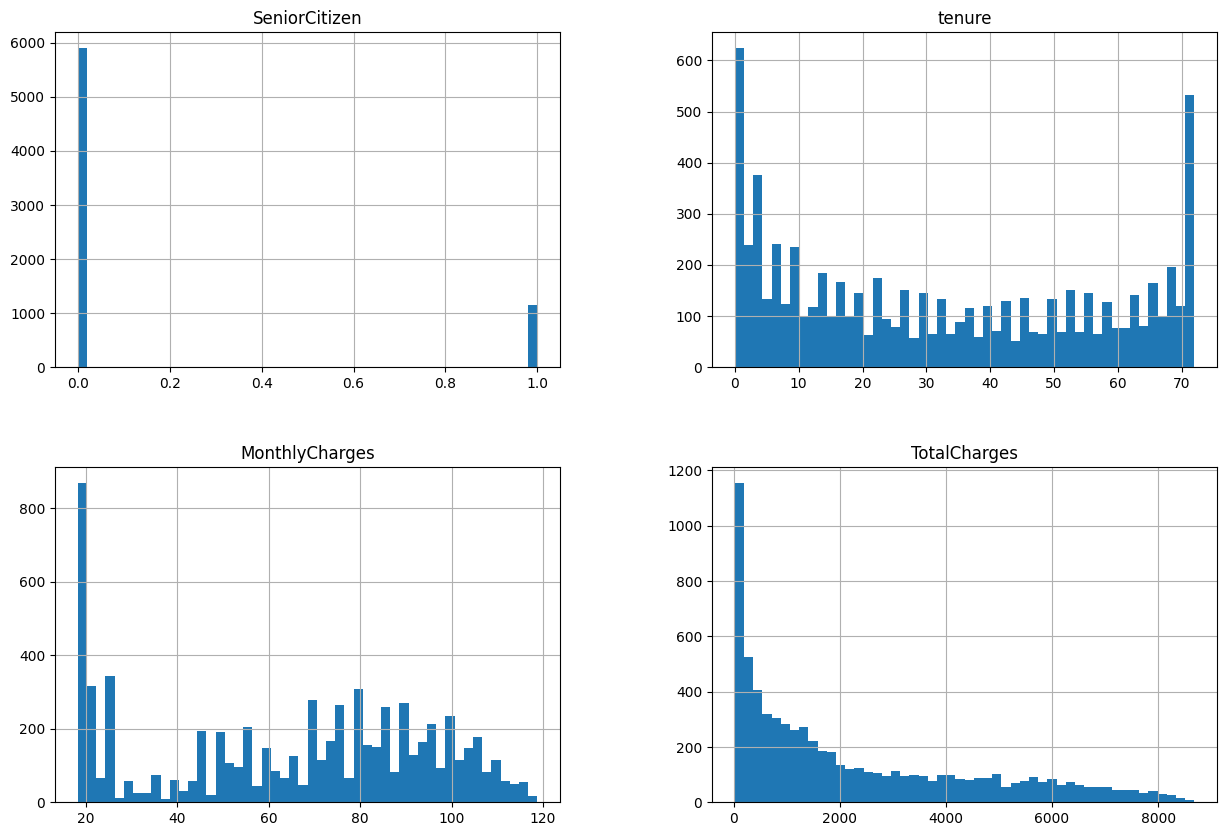

In [7]:
import matplotlib.pyplot as plt

df.hist(bins = 50, figsize= (15,10))
plt.show()

By analysing the histograms, first we can see distribution we saw earlier when using .describe(), marjority of the clients being not senior, 83%. 
Moreover, with the tenure histogram, we can see that we have a lot of clients that started using our service, so maybe we can infer that our publicity is being effective. We also have a lot of clients that are using our service for the maximum of time analysed, so maybe we can think in ways to increase the user that are churning on the middle of the way.
Finally, we have a left-tail distribution to the MonthlyCharges, maybe meaning that we need to improve our expensier services, for them to have more clients.

OBS: We have 2 features that are "tail heavy": they extend to much farther to the left of the median than to the right. This can make a bit difficult to the model after detect some patterns. Maybe after I will try to transform this features in a more bell shaped distribution.

# Creating the Testset

I’m going to create the test set now, before preprocessing and feature engineering, to avoid data leakage and make sure the evaluation stays unbiased.

** Important: We want our test set to represent the full dataset well. Our target feature “Churn” is imbalanced (73% No, 27% Yes), so we use stratified sampling to ensure both train and test sets have the same churn proportions. This makes our model evaluation reliable. 

In [8]:
# Creating Stratified Test Set
from sklearn.model_selection import StratifiedShuffleSplit

split = StratifiedShuffleSplit(n_splits = 1, test_size = 0.2, random_state = 42)
for train_idx, test_idx in split.split(df, df["Churn"]):
    strat_train_set = df.iloc[train_idx].copy()
    strat_test_set = df.iloc[test_idx].copy()

# Verification
print("Full:", df['Churn'].value_counts(normalize=True).round(4))
print("Train:", strat_train_set['Churn'].value_counts(normalize=True).round(4))
print("Test:", strat_test_set['Churn'].value_counts(normalize=True).round(4))

Full: Churn
No     0.7346
Yes    0.2654
Name: proportion, dtype: float64
Train: Churn
No     0.7346
Yes    0.2654
Name: proportion, dtype: float64
Test: Churn
No     0.7346
Yes    0.2654
Name: proportion, dtype: float64


# EDA - Exploratory Data Analysis

Let’s make a copy of the training set so we can explore, visualize, and try small data manipulations to gain insights—without accidentally modifying the original training data.

In [9]:
eda_df = strat_train_set.copy()


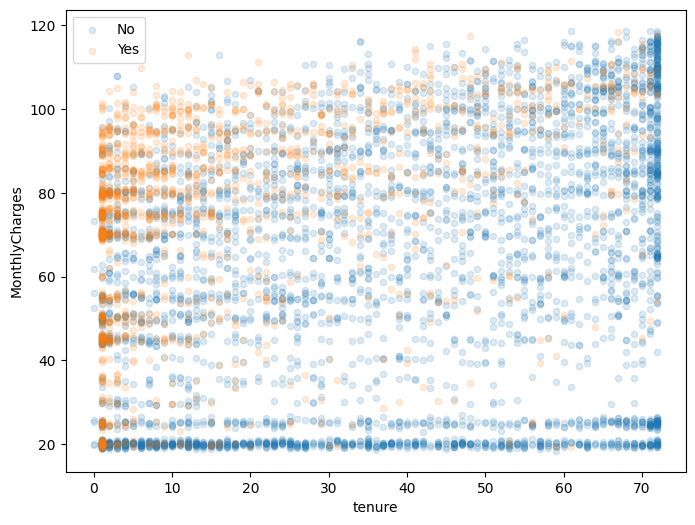

In [10]:
import matplotlib.pyplot as plt

ax = eda_df[eda_df["Churn"] == "No"].plot(kind = "scatter", x = "tenure", y = "MonthlyCharges", alpha = 0.15, label = "No", 
color = "tab:blue", figsize = (8,6))

eda_df[eda_df["Churn"] == "Yes"].plot(kind = "scatter", x = "tenure", y = "MonthlyCharges", alpha = 0.15, label = "Yes",
color = "tab:orange", ax = ax)

plt.legend()
plt.show()

### A few insights

- Churn seems concentrated among customers with low tenure, suggesting newer customers are more likely to churn.
- Churn also appears more common for customers with higher MonthlyCharges, especially at low tenure.
- Question: are high MonthlyCharges more common in month-to-month contracts, and do those contracts have higher churn?
- Possible hypothesis: retention offers or pricing incentives for early-tenure / month-to-month customers might reduce churn, but we need more analysis to confirm.

## Churn rates by Tenure bins

Let’s quantify churn rate across tenure groups to better understand when churn is most common during a customer’s time with the service.

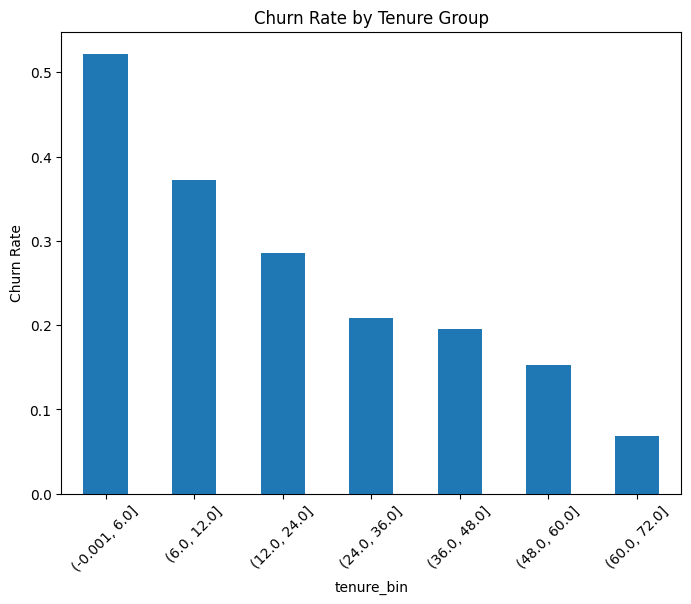

Churn            No  Yes
tenure_bin              
(-0.001, 6.0]   559  611
(6.0, 12.0]     356  211
(12.0, 24.0]    584  234
(24.0, 36.0]    529  140
(36.0, 48.0]    500  121
(48.0, 60.0]    557  101
(60.0, 72.0]   1054   77
Churn             No    Yes
tenure_bin                 
(-0.001, 6.0]  0.478  0.522
(6.0, 12.0]    0.628  0.372
(12.0, 24.0]   0.714  0.286
(24.0, 36.0]   0.791  0.209
(36.0, 48.0]   0.805  0.195
(48.0, 60.0]   0.847  0.153
(60.0, 72.0]   0.932  0.068


In [11]:
# Creating the Bins
eda_df["tenure_bin"] = pd.cut(
    eda_df["tenure"],
    bins = [0, 6, 12, 24, 36, 48, 60, 72],
    include_lowest = True
)

# Churn rate per bin

tenure_churn_rate = pd.crosstab(eda_df["tenure_bin"], eda_df["Churn"], normalize = "index").round(3)
tenure_counts = pd.crosstab(eda_df["tenure_bin"], eda_df["Churn"])
tenure_churn_rate["Yes"].plot(kind = "bar", figsize = (8,6), title = "Churn Rate by Tenure Group", ylabel = "Churn Rate")
plt.xticks(rotation = 45)
plt.show()

print(tenure_counts)
print(tenure_churn_rate)

By calculating churn rate for each tenure group, we can identify which customer segments have the highest churn. And for example, if the company decides that a churn rate above 20% is unacceptable, then the groups up to about 36 months tenure exceed this threshold (0–6 months: 52.2%, 6–12: 37.2%, 12–24: 28.6%, 24–36: 20.9%). After ~36 months, churn drops below 20% and keeps decreasing as tenure increases.

This suggests the first months are the most critical for retention: even if acquisition is bringing in many new customers, churn is much higher early on, so improving onboarding, support, or early incentives could have a big impact.

## Churn rates by MonthlyCharges bin

Let's also quantify the churn rate by MonthlyCharges, so we can have a better understanding of when, in a interval, the churn is happening the most.

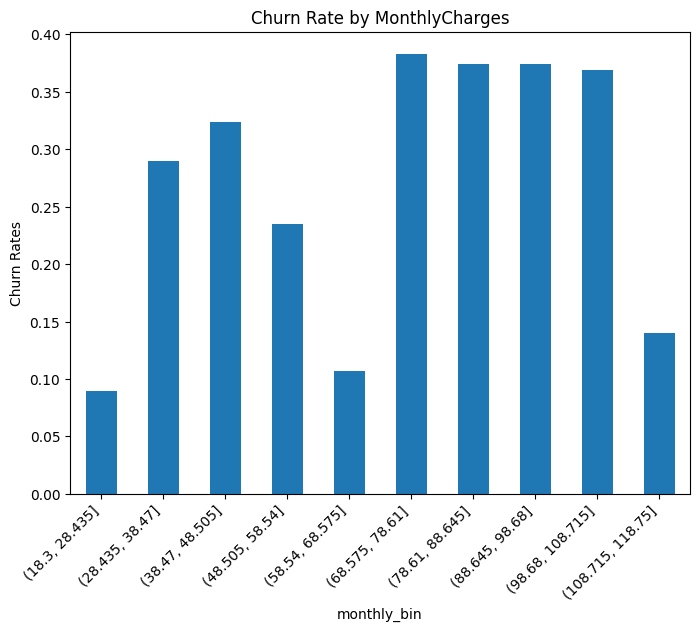

Churn                No  Yes
monthly_bin                 
(18.3, 28.435]     1162  115
(28.435, 38.47]     110   45
(38.47, 48.505]     207   99
(48.505, 58.54]     380  117
(58.54, 68.575]     334   40
(68.575, 78.61]     429  266
(78.61, 88.645]     490  293
(88.645, 98.68]     435  260
(98.68, 108.715]    389  227
(108.715, 118.75]   203   33
Churn                 No    Yes
monthly_bin                    
(18.3, 28.435]     0.910  0.090
(28.435, 38.47]    0.710  0.290
(38.47, 48.505]    0.676  0.324
(48.505, 58.54]    0.765  0.235
(58.54, 68.575]    0.893  0.107
(68.575, 78.61]    0.617  0.383
(78.61, 88.645]    0.626  0.374
(88.645, 98.68]    0.626  0.374
(98.68, 108.715]   0.631  0.369
(108.715, 118.75]  0.860  0.140


In [12]:
eda_df["monthly_bin"] = pd.cut(
    eda_df["MonthlyCharges"], bins = 10
)

monthly_churn_rates = pd.crosstab(eda_df["monthly_bin"], eda_df["Churn"], normalize = "index").round(3)
monthly_churn_counts = pd.crosstab(eda_df["monthly_bin"], eda_df["Churn"])

monthly_churn_rates["Yes"].plot(kind = "bar", figsize = (8,6), title = "Churn Rate by MonthlyCharges", ylabel = "Churn Rates")
plt.xticks(rotation = 45, ha = "right")
plt.show()

print(monthly_churn_counts)
print(monthly_churn_rates)

### More Doubts than Insights

- Churn rate is very low for customers with the lowest MonthlyCharges (18–28).
- Churn increases a lot for customers with mid-to-high MonthlyCharges (around 68–108), reaching ~37–38%.
- At the very highest MonthlyCharges (108–118), churn decreases again; this suggests this group may be different, so we should cross-check with Contract and InternetService.

## Churn by Contract 

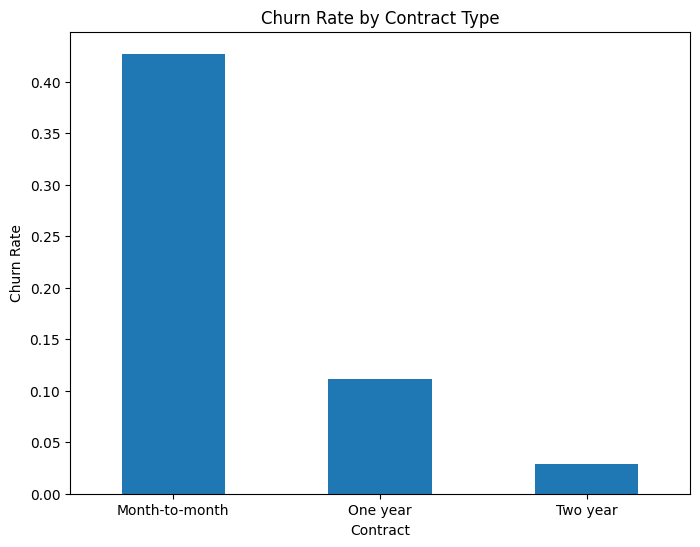

Churn             No   Yes
Contract                  
Month-to-month  1776  1326
One year        1043   130
Two year        1320    39
Churn              No    Yes
Contract                    
Month-to-month  0.573  0.427
One year        0.889  0.111
Two year        0.971  0.029


In [13]:
contract_churn_rates = pd.crosstab(eda_df["Contract"], eda_df["Churn"], normalize = "index").round(3)
contract_churn_counts = pd.crosstab(eda_df["Contract"], eda_df["Churn"])

contract_churn_rates["Yes"].plot(kind = "bar", figsize = (8,6), title = "Churn Rate by Contract Type", ylabel = "Churn Rate")
plt.xticks(rotation = 0)
plt.show()

print(contract_churn_counts)
print(contract_churn_rates)

Voilà ! Contract type is strongly associated with churn: month-to-month customers churn much more (42.7%) than one-year (11.1%) or two-year (2.9%) customers.

## Contract type rate by MonthlyCharges 

I want to check whether month-to-month contracts are more common in certain MonthlyCharges ranges (if customers on month-to-month tend to pay higher monthly charges). If they cluster in higher price bins, that suggests an association between Contract type and MonthlyCharges.

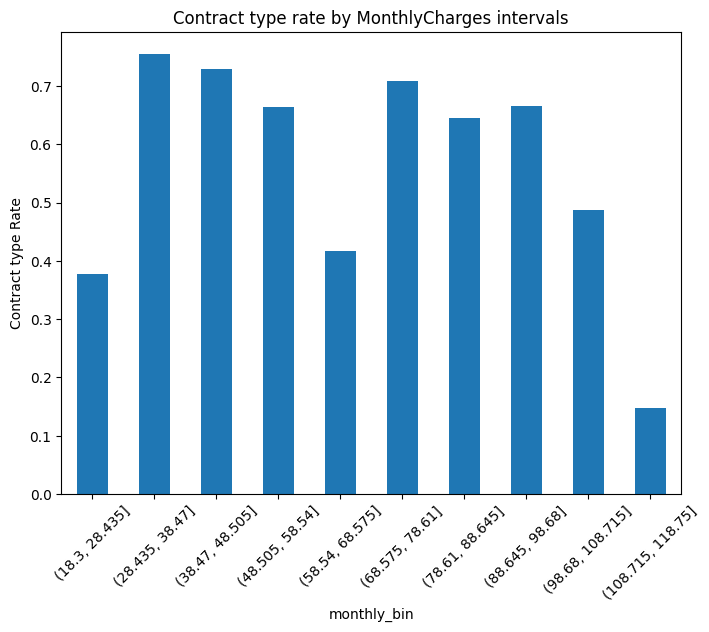

Contract           Month-to-month  One year  Two year
monthly_bin                                          
(18.3, 28.435]              0.377     0.226     0.397
(28.435, 38.47]             0.755     0.187     0.058
(38.47, 48.505]             0.729     0.144     0.127
(48.505, 58.54]             0.664     0.221     0.115
(58.54, 68.575]             0.417     0.281     0.302
(68.575, 78.61]             0.709     0.155     0.135
(78.61, 88.645]             0.645     0.142     0.213
(88.645, 98.68]             0.665     0.180     0.155
(98.68, 108.715]            0.487     0.307     0.206
(108.715, 118.75]           0.148     0.267     0.585


In [14]:
contract_monthly = pd.crosstab(eda_df["monthly_bin"], eda_df["Contract"], normalize = "index").round(3)

contract_monthly["Month-to-month"].plot(kind = "bar", figsize = (8,6), title = "Contract type rate by MonthlyCharges intervals", 
ylabel = "Contract type Rate")
plt.xticks(rotation = 45)
plt.show()

print(contract_monthly)

In [15]:
churn_contract_monthly = pd.crosstab([eda_df["Contract"], eda_df["monthly_bin"]], eda_df["Churn"], normalize = "index")

print(churn_contract_monthly)

Churn                                   No       Yes
Contract       monthly_bin                          
Month-to-month (18.3, 28.435]     0.785863  0.214137
               (28.435, 38.47]    0.632479  0.367521
               (38.47, 48.505]    0.582960  0.417040
               (48.505, 58.54]    0.678788  0.321212
               (58.54, 68.575]    0.807692  0.192308
               (68.575, 78.61]    0.486815  0.513185
               (78.61, 88.645]    0.451485  0.548515
               (88.645, 98.68]    0.482684  0.517316
               (98.68, 108.715]   0.426667  0.573333
               (108.715, 118.75]  0.714286  0.285714
One year       (18.3, 28.435]     0.975779  0.024221
               (28.435, 38.47]    0.931034  0.068966
               (38.47, 48.505]    0.886364  0.113636
               (48.505, 58.54]    0.927273  0.072727
               (58.54, 68.575]    0.914286  0.085714
               (68.575, 78.61]    0.898148  0.101852
               (78.61, 88.645]    0.882883  0.

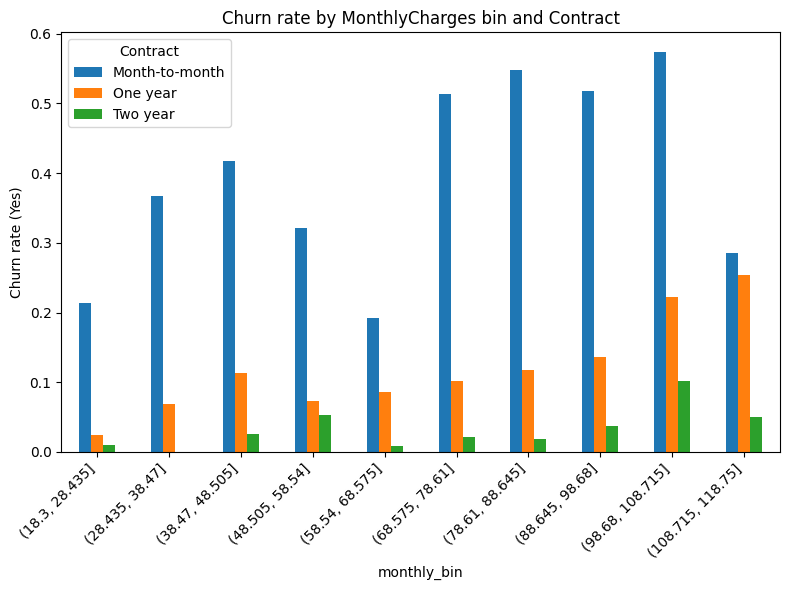

In [16]:
import matplotlib.pyplot as plt

yes_churn_rate = churn_contract_monthly["Yes"]

plot_df = yes_churn_rate.unstack("Contract")

ax = plot_df.plot(kind = "bar", figsize = (8,6))
ax.set_title("Churn rate by MonthlyCharges bin and Contract")
ax.set_ylabel("Churn rate (Yes)")
plt.xticks(rotation = 45, ha= "right")
plt.tight_layout()
plt.show()

MonthlyCharges and Contract type are associated: most mid-to-high MonthlyCharges bins contain a large proportion of month-to-month customers, while the very highest MonthlyCharges bin is dominated by two-year contracts. This helps explain the churn pattern by MonthlyCharges: bins where month-to-month customers dominate show much higher churn, whereas the top price bin shows lower churn, likely because it contains many two-year customers who churn less.

### *Confounding Effect or Ommited Variable Bias - Contract to MonthlyCharges

MonthlyCharges and Contract type are associated: many mid‑to‑high MonthlyCharges bins contain a larger proportion of month‑to‑month customers. Since month‑to‑month customers churn much more than one‑year or two‑year customers, churn also appears higher in those MonthlyCharges bins. This is an example of a confounding effect: Contract type is related to both MonthlyCharges and churn, so part of the apparent MonthlyCharges–churn relationship is explained by differences in contract mix across price ranges.

### Looking for Correlations

Since we only have four numerical features, we’ll briefly check their correlations to validate our main hypotheses and see if any additional patterns appear.

In [17]:
num_cols = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]
corr = eda_df[num_cols].corr(numeric_only = True).round(2)

corr

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.00,0.02,0.22,0.10
tenure,0.02,1.00,0.26,0.83
MonthlyCharges,0.22,0.26,1.00,0.65
TotalCharges,0.10,0.83,0.65,1.00


TotalCharges is strongly correlated with tenure (0.83), which is expected since total spending grows with time. MonthlyCharges is also positively correlated with TotalCharges (0.65), while SeniorCitizen shows only weak linear correlation with the other numeric features.

In [18]:
eda_df["Churn01"] = (eda_df["Churn"] == "Yes").astype(int)
corr_with_churn = eda_df[num_cols + ["Churn01"]].corr(numeric_only = True)["Churn01"].sort_values(ascending = False).round(3)

corr_with_churn

Churn01           1.000
MonthlyCharges    0.198
SeniorCitizen     0.146
TotalCharges     -0.195
tenure           -0.346
Name: Churn01, dtype: float64

- tenure  = -0.346 (strongest here, moderate negative): customers with longer tenure are less likely to churn; churn is concentrated among newer customers.
- MonthlyCharges  = +0.198 (weak positive): higher monthly charges are slightly associated with higher churn, but the relationship is not very strong (and you already saw it can be partly explained by Contract type).
- TotalCharges  = -0.195 (weak negative): customers who have paid more in total tend to churn less; this is expected because TotalCharges increases with tenure, so it’s closely related to tenure.
- SeniorCitizen  = +0.146 (weak positive): seniors churn a bit more on average, but this effect is small compared to tenure.

Among numeric variables, tenure shows the strongest linear relationship with churn (r = −0.346), indicating that customers who stay longer are less likely to churn. MonthlyCharges has a weak positive correlation with churn (r = 0.198), while TotalCharges is weakly negative (r = −0.195), likely reflecting its dependence on tenure. SeniorCitizen shows a small positive correlation (r = 0.146), suggesting slightly higher churn among seniors, but the effect is limited.

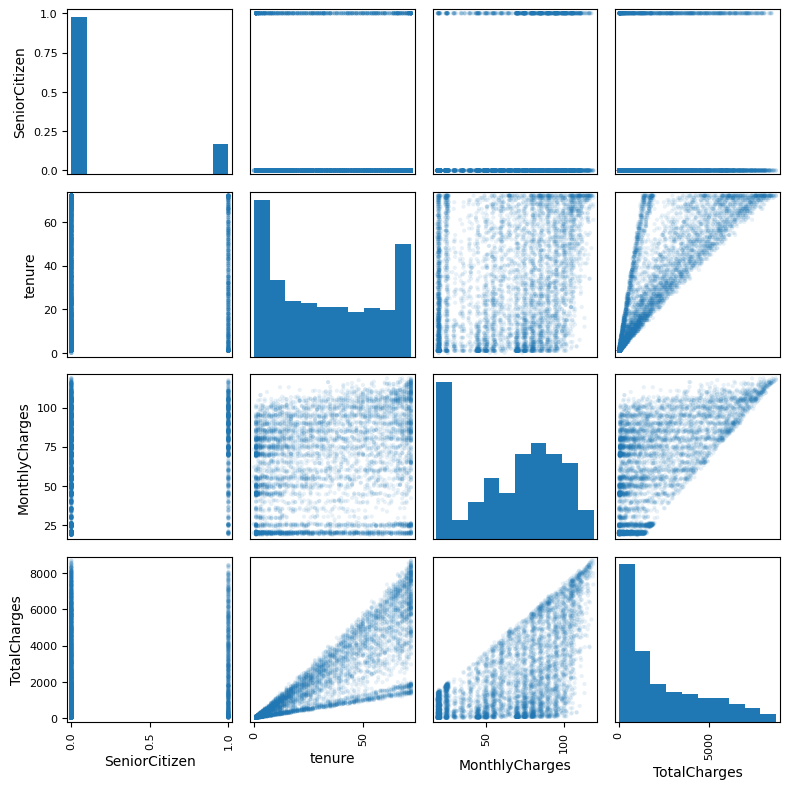

In [19]:
from pandas.plotting import scatter_matrix
num_cols_churn = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]
axes = scatter_matrix(eda_df[num_cols_churn], figsize = (8,8), alpha = 0.1, diagonal = "hist", marker = ".")

plt.tight_layout()
plt.show()

I tried a scatter matrix, but because tenure is discrete, SeniorCitizen is binary, and TotalCharges is strongly dependent on tenure and MonthlyCharges, the plot is hard to read and adds limited insight for this dataset; therefore I focus on targeted plots and churn-rate crosstabs instead.

### Churn rate by InternetService

Churn               No    Yes
InternetService              
DSL              0.813  0.187
Fiber optic      0.579  0.421
No               0.928  0.072


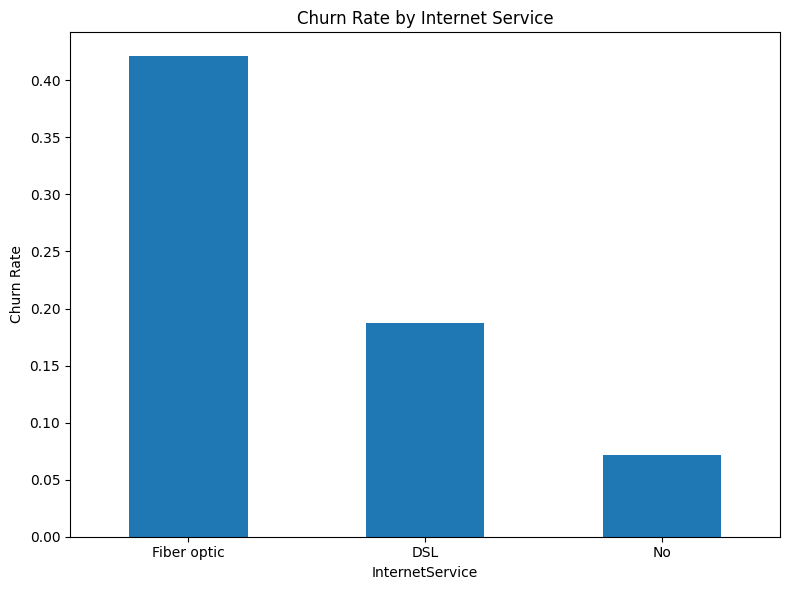

In [20]:
internet_churn = pd.crosstab(eda_df["InternetService"], eda_df["Churn"], normalize = "index").round(3)
print(internet_churn)

internet_churn["Yes"].sort_values(ascending = False).plot(kind = "bar", figsize = (8,6), title = "Churn Rate by Internet Service", 
ylabel = "Churn Rate")
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()


- Customers with No internet service have very low churn (7.2%), so they are a low-risk segment.
- Customers with Fiber optic have very high churn (42.1%)—this is the highest-risk group.
- Customers with DSL have moderate churn (18.7%).

This suggests that Fiber optic users are the highest-risk segment and warrant focused retention strategies.

### Internet Service And Contract - Confounding Check

Churn                              No    Yes
InternetService Contract                    
DSL             Month-to-month  0.682  0.318
                One year        0.905  0.095
                Two year        0.980  0.020
Fiber optic     Month-to-month  0.449  0.551
                One year        0.814  0.186
                Two year        0.929  0.071
No              Month-to-month  0.818  0.182
                One year        0.979  0.021
                Two year        0.990  0.010


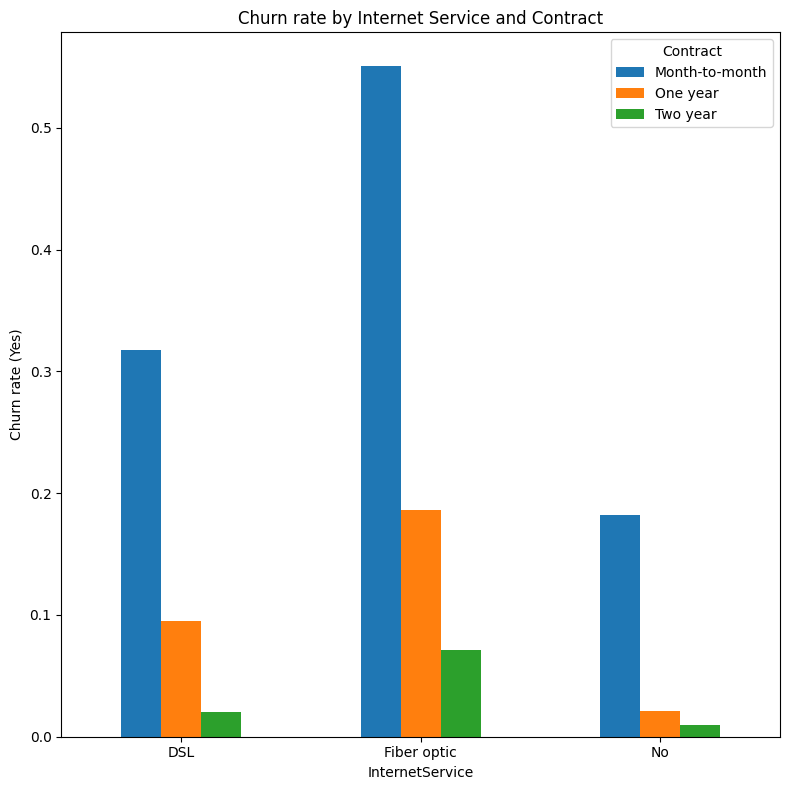

In [21]:
internet_contract_churn = pd.crosstab([eda_df["InternetService"], eda_df["Contract"]], eda_df["Churn"], normalize = "index").round(3)
print(internet_contract_churn)

yes_ic = internet_contract_churn["Yes"].unstack("Contract")

ax = yes_ic.plot(kind = "bar", figsize = (8,8))
ax.set_title("Churn rate by Internet Service and Contract")
ax.set_ylabel("Churn rate (Yes)")
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()

### Key insight (Contract type is strong but Internet Service still matter):
- Contract type is the strongest single predictor of churn, but InternetService provides additional independent signal: among month-to-month customers, Fiber optic users churn at 55.1% compared to 31.8% for DSL users. This suggests that Fiber optic customers may face service quality, pricing, or competitive issues that drive higher churn, even after controlling for contract length.

### Add-on Features (Only amoung customers with internet)

In [22]:
internet_users = eda_df[eda_df["InternetService"] != "No"].copy()
internet_users["InternetService"].value_counts() 

InternetService
Fiber optic    2483
DSL            1937
Name: count, dtype: int64

For internet add-on features (TechSupport, OnlineSecurity, etc), I restricted the analysis to customers who actually have internet service, because ‘No internet service’ is a different situation than simply not subscribing to the add-on.

In [23]:
addon_cols = ["TechSupport", "OnlineSecurity", "OnlineBackup", "DeviceProtection"]

for col in addon_cols:
    tab = pd.crosstab(internet_users[col], internet_users["Churn"], normalize = "index").round(3)
    print(f"\n {col}")
    print(tab)


 TechSupport
Churn           No    Yes
TechSupport              
No           0.582  0.418
Yes          0.848  0.152

 OnlineSecurity
Churn              No    Yes
OnlineSecurity              
No              0.581  0.419
Yes             0.856  0.144

 OnlineBackup
Churn            No    Yes
OnlineBackup              
No            0.599  0.401
Yes           0.784  0.216

 DeviceProtection
Churn                No    Yes
DeviceProtection              
No                0.610  0.390
Yes               0.772  0.228


### Surprising Insight
Among internet users, support/security add-ons are strongly associated with lower churn. For example, TechSupport customers churn at 15.2% vs 41.8% without TechSupport, and OnlineSecurity customers churn at 14.4% vs 41.9%.

Churn decreases as the number of subscribed add-on services increases, suggesting that more ‘bundled’ customers are less likely to leave

### Quick Checks to Finish EDA (PaperlessBilling, PaymentMethod and PhoneService)

In [24]:
quick_cols = ["gender","Partner","Dependents","PhoneService","PaperlessBilling","PaymentMethod"]

for col in quick_cols:
    churn_yes = pd.crosstab(eda_df[col], eda_df["Churn"], normalize="index")["Yes"].sort_values(ascending=False).round(3)
    print(f"\n{col} — churn rate (Yes)")
    print(churn_yes)



gender — churn rate (Yes)
gender
Female    0.266
Male      0.264
Name: Yes, dtype: float64

Partner — churn rate (Yes)
Partner
No     0.328
Yes    0.199
Name: Yes, dtype: float64

Dependents — churn rate (Yes)
Dependents
No     0.314
Yes    0.152
Name: Yes, dtype: float64

PhoneService — churn rate (Yes)
PhoneService
Yes    0.268
No     0.242
Name: Yes, dtype: float64

PaperlessBilling — churn rate (Yes)
PaperlessBilling
Yes    0.338
No     0.160
Name: Yes, dtype: float64

PaymentMethod — churn rate (Yes)
PaymentMethod
Electronic check             0.457
Mailed check                 0.193
Bank transfer (automatic)    0.162
Credit card (automatic)      0.149
Name: Yes, dtype: float64


### Main takeaways
- Gender shows almost no difference in churn (26.6% vs 26.4%), so it likely has limited predictive power on its own.
- Partner and Dependents are both associated with lower churn: customers without a partner churn more (32.8% vs 19.9%), and customers without dependents churn more (31.4% vs 15.2%).
- PaperlessBilling shows a strong association with churn (33.8% for “Yes” vs 16.0% for “No”).
- PaymentMethod shows one of the strongest differences: Electronic check has very high churn (45.7%), while automatic payments are much lower (~15–16%).
- PhoneService shows only a small difference (26.8% vs 24.2%), so it’s likely a weaker driver compared to billing/payment and contract features.

## Sanity Test - Statistical Validation (Chi-square)

In [25]:
import pandas as pd
from scipy.stats import chi2_contingency

features = ["Contract", "InternetService", "PaymentMethod", "PaperlessBilling"]

results = []

for feature in features:
    contingency = pd.crosstab(eda_df[feature], eda_df["Churn"])
    chi2, p_value, dof, expected = chi2_contingency(contingency)

    results.append({
        "Feature": feature,
        "Chi-square": chi2,
        "dof": dof,
        "p_value": p_value
    })

chi_summary = pd.DataFrame(results).sort_values("Chi-square", ascending = False)

chi_summary["Chi-square"] = chi_summary["Chi-square"].round(2)
chi_summary["p_value"] = chi_summary["p_value"].apply(lambda x: f"{x:.2e}") 

chi_summary

,Feature,Chi-square,dof,p_value
0,Contract,952.31,2,1.62e-207
1,InternetService,600.85,2,3.37e-131
2,PaymentMethod,545.21,3,7.57e-118
3,PaperlessBilling,219.92,1,9.40e-50


Chi-square tests confirm that Contract, InternetService, PaymentMethod, and PaperlessBilling are all significantly associated with churn (all p-values ≪ 0.001). Among these, Contract shows the strongest association (χ² = 952.31), followed by InternetService (χ² = 600.85) and PaymentMethod (χ² = 545.21), while PaperlessBilling also remains significant (χ² = 219.92). This statistical validation supports the patterns observed in the churn-rate crosstabs.

### Preparing train/test datasets for modeling and Atribute Combinations

I will use the stratified train/test split created earlier. From the training and test sets, I separate the target variable ( Churn ) from the predictors (all other columns). Then I create two feature sets: (1) a baseline dataset with original features only, and (2) an engineered dataset that adds new derived features. This allows a fair comparison of model performance with and without feature engineering, using the same train/test split.

In [26]:
train_df = strat_train_set.copy()
test_df = strat_test_set.copy()

y_train = (train_df["Churn"] == "Yes").astype(int)
y_test = (test_df["Churn"] == "Yes").astype(int)

x_train_base = train_df.drop(columns = ["Churn"])
x_test_base = test_df.drop(columns = ["Churn"])

x_train_eng = x_train_base.copy()
x_test_eng = x_test_base.copy()

def add_engineered_features(X):
    X = X.copy()
    tenure_safe = X["tenure"].replace(0, np.nan)
    X["avg_monthly_charge"] = X["TotalCharges"] / tenure_safe
    X["charges_growth"] = X["MonthlyCharges"] / X["avg_monthly_charge"]
    X["is_long_term_contract"] = X["Contract"].isin(["One year", "Two year"]).astype(int)
    X["is_auto_pay"] = X["PaymentMethod"].isin(
        ["Bank transfer (automatic)", "Credit card (automatic)"]
    ).astype(int)
    return X

x_train_eng = add_engineered_features(x_train_eng)
x_test_eng  = add_engineered_features(x_test_eng)


In this step, I create a few derived features to capture customer behavior more directly than raw totals. In Telco churn, totals such as TotalCharges are strongly influenced by tenure, so I create normalized and comparative features (TotalCharges per month)

- avg_monthly_charge = TotalCharges / tenure : average monthly spend across the customer lifetime (normalizes TotalCharges by time as a customer).

- charges_growth = MonthlyCharges / avg_monthly_charge : compares the current monthly bill to the customer’s historical average; values > 1 suggest the current bill is higher than their past average.

- is_long_term_contract : 1 for “One year” or “Two year” contracts, else 0 (captures customer commitment).

- is_auto_pay : 1 for automatic payment methods (bank transfer automatic, credit card automatic), else 0 (captures autopay behavior).

## Pre-Processing 

### Handling Missing Values

After converting  TotalCharges  from text to numeric, some values became missing ( NaN ) because blank strings in the original dataset are interpreted as missing numbers. Therefore, before choosing a treatment strategy, I inspected the rows with missing  TotalCharges  to understand the pattern and avoid making unrealistic replacements.

In [27]:
train_missing = train_df.isna().sum().sort_values(ascending = False)
test_missing = test_df.isna().sum().sort_values(ascending = False)

print("Train missing (top):")
print(train_missing[train_missing > 0])

print("Test missing (top):")
print(test_missing[test_missing > 0])


Train missing (top):
TotalCharges    8
dtype: int64
Test missing (top):
TotalCharges    3
dtype: int64


In [28]:
missing_tc_train = train_df[train_df["TotalCharges"].isna()]
print(missing_tc_train[["tenure", "MonthlyCharges", "TotalCharges", "Contract", "Churn"]].head(20))
print(missing_tc_train["tenure"].value_counts())

missing_tc_test = test_df[test_df["TotalCharges"].isna()]
print(missing_tc_test[["tenure", "MonthlyCharges", "TotalCharges", "Contract", "Churn"]].head(20))
print(missing_tc_test["tenure"].value_counts())



      tenure  MonthlyCharges  TotalCharges  Contract Churn
6670       0           73.35           NaN  Two year    No
4380       0           20.00           NaN  Two year    No
3826       0           25.35           NaN  Two year    No
488        0           52.55           NaN  Two year    No
1082       0           25.75           NaN  Two year    No
1340       0           56.05           NaN  Two year    No
6754       0           61.90           NaN  Two year    No
3331       0           19.85           NaN  Two year    No
tenure
0    8
Name: count, dtype: int64
      tenure  MonthlyCharges  TotalCharges  Contract Churn
753        0           20.25           NaN  Two year    No
5218       0           19.70           NaN  One year    No
936        0           80.85           NaN  Two year    No
tenure
0    3
Name: count, dtype: int64


The inspection shows that the missing  TotalCharges  values come from blank entries that became  NaN  after converting the column to numeric, and these cases occur for customers with  tenure = 0  (new customers in their first month). Instead of dropping these rows and slightly reducing the dataset, I will keep them and impute missing numeric values using the median computed from the training data. Median imputation is a simple, robust choice that is less sensitive to outliers than the mean and allows the preprocessing pipeline to handle missing values consistently for both the training set, the test set, and any future new data.

### Pipeline (imputation + encoding + scaling)

In this step, I build a preprocessing pipeline that can be applied consistently to both training and test data. Numerical features are imputed using the median (learned from the training set) and scaled using standardization, while categorical features are imputed with the most frequent value and one‑hot encoded. This approach avoids data leakage and makes the transformations reusable for new data.

In [29]:
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

num_pipe = Pipeline(steps = [
    ("imputer", SimpleImputer(strategy = "median")),
    ("scaler", StandardScaler())
])

cat_pipe = Pipeline(steps = [
    ("imputer", SimpleImputer(strategy = "most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown= "ignore"))
])

preprocess = ColumnTransformer(
    transformers = [
        ("num", num_pipe, make_column_selector(dtype_include = np.number)),
        ("cat", cat_pipe, make_column_selector(dtype_include = object)),
    ],
    remainder= "drop"
)

## Training a baseline model - Logistic Regression

Now that the preprocessing pipeline is defined, I train a baseline classification model. Logistic Regression is a simple and interpretable classifier that often provides a strong baseline for churn prediction. The model is trained using the training set only, and evaluation is performed on the held‑out test set.

In [30]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

baseline_clf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=2000))
])

baseline_clf.fit(x_train_base, y_train)


,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### Evaluation

In [31]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred = baseline_clf.predict(x_test_base)
y_proba = baseline_clf.predict_proba(x_test_base)[:, 1]

print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred))
print("\nROC-AUC:", roc_auc_score(y_test, y_proba))


Confusion matrix:
 [[924 111]
 [166 208]]

Classification report:
               precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.65      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.80      0.80      0.80      1409


ROC-AUC: 0.8417215634606938


On the test set, the baseline Logistic Regression model achieved an accuracy of 0.80 and a ROC‑AUC of 0.842, indicating good overall discrimination between churners and non‑churners when using predicted probabilities. The confusion matrix shows 924 true negatives and 208 true positives, with 111 false positives and 166 false negatives. For the non‑churn class (0), performance is strong (precision 0.85, recall 0.89, F1 0.87), meaning the model identifies non‑churners reliably. For the churn class (1), the model is weaker (precision 0.65, recall 0.56, F1 0.60), meaning it misses a noticeable portion of true churners (recall 56%), which is important because detecting churners is usually the business priority.

### Cross Validation

A single test-set evaluation can be sensitive to the particular split of the data. To obtain a more reliable estimate of model performance, I apply k‑fold cross‑validation on the training set using the full preprocessing+model pipeline. This trains the model multiple times on different folds and reports the mean and standard deviation of the chosen metric, while keeping the test set untouched for the final unbiased evaluation.

In [32]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    baseline_clf,
    x_train_base,
    y_train,
    cv=5,
    scoring="roc_auc"
)

print("CV ROC-AUC scores:", cv_scores)
print("Mean:", cv_scores.mean())
print("Std:", cv_scores.std())


CV ROC-AUC scores: [0.86362351 0.85287916 0.85073837 0.83566801 0.82405075]
Mean: 0.8453919596504565
Std: 0.013907080689756369


Using 5-fold cross-validation on the training set, the baseline pipeline achieved a mean ROC‑AUC of 0.845 (std = 0.014). This is very close to the ROC‑AUC on the held-out test set (0.842), suggesting the model generalizes reasonably well and is not heavily overfitting.

### Logistic Regression using feature engineering variables

In [33]:
baseline_clf.fit(x_train_eng, y_train)

y_pred_eng = baseline_clf.predict(x_test_eng)
y_proba_eng = baseline_clf.predict_proba(x_test_eng)[:, 1]

print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_eng))
print("\nClassification report:\n", classification_report(y_test, y_pred_eng))
print("\nROC-AUC:", roc_auc_score(y_test, y_proba_eng))


Confusion matrix:
 [[925 110]
 [165 209]]

Classification report:
               precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409


ROC-AUC: 0.8417499806246609


After training Logistic Regression with the baseline features and with the engineered features, the results are almost identical. The ROC‑AUC remains ~0.842 in both cases, and the confusion matrix changes by only one observation. This suggests that, for Logistic Regression, the engineered features do not add significant predictive information beyond the original variables, so the baseline feature set is already sufficient for this model.

In [34]:
cv_scores_eng = cross_val_score(
    baseline_clf,
    x_train_eng,
    y_train,
    cv=5,
    scoring="roc_auc"
)

print("CV ROC-AUC scores:", cv_scores_eng)
print("Mean:", cv_scores_eng.mean())
print("Std:", cv_scores_eng.std())


CV ROC-AUC scores: [0.86351849 0.85241465 0.85069798 0.83571244 0.82253825]
Mean: 0.8449763615723207
Std: 0.014291010279444169


Although engineered features did not improve Logistic Regression, they may still benefit non‑linear models such as Random Forest or XGBoost. Therefore, I compare each model using cross-validation with both the baseline and engineered feature sets, and keep only the best-performing configuration for final test evaluation.

## Trying other more complex models (Trees, RandomForest and XGboost)

In [35]:
!pip install xgboost


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


To compare additional models efficiently, I evaluated three tree-based classifiers (Decision Tree, Random Forest, and XGBoost) both with and without the engineered features. To avoid repeating the same training and evaluation code for each combination, I used a loop that builds the same preprocessing+model pipeline and reports the same metrics (test-set confusion matrix/classification report/ROC-AUC and cross-validated ROC-AUC) for each run. This makes the workflow more concise and ensures every model is assessed consistently under the same evaluation procedure.

In [36]:
def evaluate_pipeline_cv_only(model, preprocess, x_train, y_train, cv=5, name="Model"):
    pipe = Pipeline([
        ("preprocess", preprocess),
        ("model", model)
    ])

    cv_scores = cross_val_score(pipe, x_train, y_train, cv=cv, scoring="roc_auc")

    print(f"\n================ {name} | CV (train only) ================")
    print("CV ROC-AUC scores:", cv_scores)
    print("Mean:", cv_scores.mean())
    print("Std:", cv_scores.std())

    return {"name": name, "cv_mean": cv_scores.mean(), "cv_std": cv_scores.std()}

In [37]:
datasets_train_only = {
    "BASE": (x_train_base),
    "ENG":  (x_train_eng),
}


In [38]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
}


In [39]:
import xgboost as xgb

models["XGBoost"] = xgb.XGBClassifier(
    random_state=42,
    n_estimators=400,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric="logloss",
    n_jobs=-1
)


In [40]:
results_cv = []
for ds_name, Xtr in datasets_train_only.items():
    for model_name, model in models.items():
        res = evaluate_pipeline_cv_only(
            model=model,
            preprocess=preprocess,
            x_train=Xtr, y_train=y_train,
            cv=5,
            name=f"{model_name} ({ds_name})"
        )
        results_cv.append(res)


================ DecisionTree (BASE) | CV (train only) ================
CV ROC-AUC scores: [0.68947417 0.67860461 0.66248606 0.67470271 0.6534195 ]
Mean: 0.6717374116866782
Std: 0.012583142824327641

================ RandomForest (BASE) | CV (train only) ================
CV ROC-AUC scores: [0.84828656 0.83721907 0.83607193 0.82124796 0.81425995]
Mean: 0.8314170937943748
Std: 0.01214650779207808

================ XGBoost (BASE) | CV (train only) ================
CV ROC-AUC scores: [0.85701533 0.85013451 0.83886102 0.83177015 0.82173953]
Mean: 0.8399041088014145
Std: 0.012606792351556866

================ DecisionTree (ENG) | CV (train only) ================
CV ROC-AUC scores: [0.70777592 0.69244705 0.68134522 0.67776849 0.67910771]
Mean: 0.6876888769362878
Std: 0.011299752084028268

================ RandomForest (ENG) | CV (train only) ================
CV ROC-AUC scores: [0.85275799 0.83635872 0.8368414  0.82690894 0.80991455]
Mean: 0.8325563185253733
Std: 0.01403901846520612

========

Using 5-fold cross-validation ROC-AUC on the training set, XGBoost achieved the best mean performance (~0.84), with RandomForest close behind (~0.83), while a single Decision Tree lagged far behind (~0.67–0.69). Therefore, we select XGBoost (BASE) as the model to fine-tune, and we keep the test set untouched for a single final evaluation after tuning.

## XGBoost Fine-Tune

After selecting XGBoost as the most promising model based on cross-validation performance, the next step is to fine-tune its hyperparameters to further improve predictive performance. Instead of manually trying combinations (which is slow and subjective), we use  RandomizedSearchCV , which samples a fixed number of hyperparameter combinations from predefined distributions and evaluates each one using cross-validation, giving direct control over the compute budget through  n_iter .
Throughout this tuning stage, we keep the test set untouched and rely only on cross-validation scores computed on the training data, so that the test set remains an unbiased benchmark for the final model. Once the best hyperparameter configuration is found, setting  refit=True  (the default) retrains the best pipeline on the full training set, producing a final tuned model that can then be evaluated once on the test set.

In [41]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform


xgb_clf = xgb.XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

pipe = Pipeline([
    ("preprocess", preprocess),
    ("model", xgb_clf)
])

param_distributions = {
    "model__n_estimators": randint(200, 1000),
    "model__max_depth": randint(2, 8),
    "model__learning_rate": uniform(0.01, 0.2),
    "model__subsample": uniform(0.6, 0.4),
    "model__colsample_bytree": uniform(0.6, 0.4),
    "model__min_child_weight": randint(1, 10),
    "model__gamma": uniform(0.0, 5.0),
    "model__reg_lambda": uniform(0.0, 5.0),
}

search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_distributions,
    n_iter=50,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=-1,
    refit=True
)

search.fit(x_train_base, y_train)

print("Best CV ROC-AUC:", search.best_score_)
print("Best params:", search.best_params_)
best_model = search.best_estimator_


Best CV ROC-AUC: 0.8503633000752888
Best params: {'model__colsample_bytree': np.float64(0.9439761626945282), 'model__gamma': np.float64(3.4015376929388985), 'model__learning_rate': np.float64(0.1000998503939086), 'model__max_depth': 3, 'model__min_child_weight': 4, 'model__n_estimators': 800, 'model__reg_lambda': np.float64(4.828160165372797), 'model__subsample': np.float64(0.9233589392465844)}


We fine-tuned XGBoost using  RandomizedSearchCV , which tests randomly sampled hyperparameter combinations and selects the one with the highest mean cross-validated ROC-AUC ( best_score_ ).
The best configuration achieved a CV ROC-AUC of 0.8504 and favors a more regularized model (shallow trees, stronger split constraints and L2 regularization, plus mild row/column subsampling) to improve generalization.

## Analyze best model and errors - Test evaluation 

After selecting XGBoost as the best-performing model during cross-validation and fine-tuning its hyperparameters using randomized search, we now move to the final stages of the project: (1) analyzing the tuned model to understand what drives its predictions and where it makes mistakes, and (2) evaluating its performance on the held-out test set. The goal of this step is to convert the tuned model into a well-documented final solution by interpreting its behavior (feature influence and typical errors) and by reporting an unbiased estimate of performance on unseen data.

In [42]:
final_model = search.best_estimator_


feature_names = final_model.named_steps["preprocess"].get_feature_names_out()


xgb_est = final_model.named_steps["model"]
importances = xgb_est.feature_importances_

fi = (pd.DataFrame({"feature": feature_names, "importance": importances})
        .sort_values("importance", ascending=False)
        .reset_index(drop=True))

print("Top 20 features by XGBoost feature_importances_:")
print(fi.head(20).to_string(index=False))


top20 = fi.head(20)


Top 20 features by XGBoost feature_importances_:
                            feature  importance
       cat__Contract_Month-to-month    0.464919
   cat__InternetService_Fiber optic    0.102676
                cat__TechSupport_No    0.085493
             cat__OnlineSecurity_No    0.055443
cat__PaymentMethod_Electronic check    0.042508
             cat__Contract_Two year    0.027312
                        num__tenure    0.021248
            cat__InternetService_No    0.018891
                cat__StreamingTV_No    0.018099
           cat__PaperlessBilling_No    0.018097
                  num__TotalCharges    0.017419
               cat__OnlineBackup_No    0.015135
           cat__StreamingMovies_Yes    0.015096
             cat__Contract_One year    0.014343
                num__MonthlyCharges    0.013609
              cat__MultipleLines_No    0.010349
               cat__StreamingTV_Yes    0.009995
           cat__InternetService_DSL    0.008380
                 cat__Dependents_No    

To interpret the tuned XGBoost model, we inspected its feature importance scores after preprocessing (including one-hot encoded categorical variables). The model relies most strongly on contract and service-related attributes: Contract = Month-to-month is the dominant driver, followed by indicators linked to fiber-optic internet service and the absence of support/security add-ons (e.g., TechSupport = No and OnlineSecurity = No). Payment behavior also appears important (Electronic check), while customer tenure and billing variables (TotalCharges and MonthlyCharges) contribute additional signal but are less influential than the main contract/service features. Overall, the importance ranking is consistent with typical churn dynamics, where flexible contracts and limited support/security options are associated with higher churn risk.

## Evaluating the Model in the Test Set

In [43]:
final_model = search.best_estimator_

X_test_final = x_test_base  
y_test_final = y_test

y_pred = final_model.predict(X_test_final)
y_proba = final_model.predict_proba(X_test_final)[:, 1]

print("Confusion matrix:\n", confusion_matrix(y_test_final, y_pred))
print("\nClassification report:\n", classification_report(y_test_final, y_pred))
print("\nTEST ROC-AUC:", roc_auc_score(y_test_final, y_proba))


Confusion matrix:
 [[939  96]
 [175 199]]

Classification report:
               precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.67      0.53      0.59       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409


TEST ROC-AUC: 0.8480947583249373


# Conclusion

Throughout the project, we followed an end-to-end workflow to predict customer churn, starting with a stratified train/test split and building a consistent preprocessing pipeline (imputation, scaling for numeric features, and one-hot encoding for categorical features). To ensure a fair comparison between algorithms, we evaluated candidate models using cross-validation on the training set and kept the test set untouched until the end, which helps avoid optimistic performance estimates due to data leakage or repeated test-set “peeking.”

## Models
When comparing models, ensemble methods clearly outperformed a single Decision Tree, and the best results were obtained with XGBoost. After hyperparameter tuning with RandomizedSearchCV, the final XGBoost model achieved a TEST ROC-AUC of 0.848 and an accuracy of 0.81, indicating strong overall discrimination between churners and non‑churners on unseen data. However, the confusion matrix shows that the model predicts non-churn customers more reliably than churn customers (churn recall 0.53), meaning that at the default decision threshold it still misses a substantial fraction of true churners.

## Feature Importance
Feature-importance analysis suggests that churn risk is driven primarily by contract and service characteristics: “Month-to-month” contracts are the most influential signal, followed by internet service type (notably fiber optic), lack of support/security add-ons (TechSupport/OnlineSecurity), and payment method (electronic check). This aligns with a clear business interpretation: customers with flexible contracts and fewer “sticky” services/support options are more likely to leave, while longer-term contracts and additional services correlate with retention. At the same time, built-in feature importance should be interpreted cautiously (especially with correlated or high-cardinality variables), so these insights are best treated as directional rather than strictly causal.

## Overall
Overall, the tuned XGBoost model is a strong candidate for deployment as a churn risk scoring tool, since ROC-AUC shows it ranks customers by churn risk effectively. If the business goal is to catch more churners (reduce false negatives), the most practical next step is not changing the model family but tuning the decision threshold on validation data to achieve the desired precision–recall trade-off (for example, prioritizing higher recall even if it increases false positives), ideally guided by the relative cost of each error type